Import libraires

In [36]:
from google.colab import files
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from tqdm import tqdm
import sys
import os

Clonage du repo git sur le colab

In [85]:
!git clone https://github.com/alextonon/Hackaton_abeilles_tigres

Cloning into 'Hackaton_abeilles_tigres'...
remote: Enumerating objects: 722, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 722 (delta 35), reused 50 (delta 18), pack-reused 650 (from 2)
Receiving objects: 100% (722/722), 331.70 MiB | 19.88 MiB/s, done.
Resolving deltas: 100% (361/361), done.
Updating files: 100% (91/91), done.


Téléchargement des données depuis kaggle

In [38]:
# 1. Upload du fichier kaggle.json (choisir le bon fichier sur l'ordinateur)
files.upload()

# 2. Création du dossier caché et déplacement du fichier
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# 3. Sécurisation du fichier (obligatoire pour l'API Kaggle)
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [39]:
#Téléchargement du fichier depuis kaggle
!kaggle competitions download -c reconnaissance-dabeilles-francaises

 99% 985M/999M [00:52<00:00, 265MB/s]
100% 999M/999M [00:52<00:00, 19.9MB/s]


In [40]:
#Dézipage du fichier téléchargé depuis kaggle
!unzip reconnaissance-dabeilles-francaises.zip -d Hackaton_abeilles_tigres > /dev/null

In [110]:
#On se place dans le repo
%cd /content/Hackaton_abeilles_tigres/

/content/Hackaton_abeilles_tigres


In [111]:
!rm -rf Hackaton_abeilles_tigres/

In [77]:
#Déplacement des classe
!rm -rf data/train/Andrena\ dilleri data/train/Andrena\ pinguis data/train/Andrena\ prodigiosa


In [83]:
!mv processed_classes/Andrena\ dilleri data/train
!mv processed_classes/Andrena\ pinguis data/train
!mv processed_classes/Andrena\ prodigiosa data/train

mv: cannot stat 'processed_classes/Andrena dilleri': No such file or directory
mv: cannot stat 'processed_classes/Andrena pinguis': No such file or directory
mv: cannot stat 'processed_classes/Andrena prodigiosa': No such file or directory


In [112]:
!python3 lib/data/train_csv.py

Done ! 7999 lines written in data/train_corrected.csv


# __Master Pipeline__

# **0. Librairies**

In [138]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from sklearn.metrics import confusion_matrix


sys.path.append(os.path.abspath(".."))

from lib.data.dataset import BeeDataset
from lib.data.preprocessing import TorchPreprocessor
from lib.data.train_val_split import train_val_split
from lib.data.preprocessing import TorchPreprocessor
from lib.data.data_augmentation import data_augmented_loader
from lib.utils.model_saver import ModelSaver

In [139]:
## CONFIGURATION
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
NUM_EPOCHS = 25
LR = 1e-3

DROPOUT = 0.4
WEIGHT_DECAY = 1e-4

USER_NAME = 'Antonin'

NUM_CLASSES = 50

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

### **Booléen par block**

In [140]:
scheduler = True
focal_loss = False
wheigted = True
unfreeze = True
data_augmentation = False
data_differntiation = True

convnext = True

## **1. Preprocessing**

In [141]:
%cd /content/Hackaton_abeilles_tigres/notebooks

/content/Hackaton_abeilles_tigres/notebooks


In [142]:
resnet_processor_parameters = {
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "crop_size": (224, 224)
}

if convnext:
    resize_value = 230
else :
    resize_value = 256

train_preprocessor_light = TorchPreprocessor (mean = resnet_processor_parameters["mean"],
                                              std = resnet_processor_parameters["std"],
                                              normalize = True,
                                              augmentation = 'light',
                                              resize_method = 'pad',
                                              resize_value = resize_value,
                                              target_size = (224,224))

train_preprocessor_heavy = TorchPreprocessor (mean = resnet_processor_parameters["mean"],
                                              std = resnet_processor_parameters["std"],
                                              normalize = True,
                                              augmentation = 'heavy',
                                              resize_method = 'pad',
                                              resize_value = resize_value,
                                              target_size = (224,224))


val_preprocessor = TorchPreprocessor (mean = resnet_processor_parameters["mean"],
                                      std = resnet_processor_parameters["std"],
                                      normalize = True,
                                      augmentation = 'None',
                                      resize_method = 'pad',
                                      resize_value = resize_value,
                                      target_size = (224,224))

In [143]:

if data_augmentation:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), batch_size=BATCH_SIZE,  apply_augmentation = data_augmentation)
elif data_augmentation and data_differntiation:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224),
                                                     batch_size=BATCH_SIZE,
                                                     apply_augmentation = data_augmentation,
                                                     distinguish_classes=data_differntiation,
                                                     train_preprocessor_light = train_preprocessor_light,
                                                     train_preprocessor_heavy = train_preprocessor_heavy,
                                                     val_preprocessor = val_preprocessor)
else:
    train_loader, val_loader = data_augmented_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224), batch_size=BATCH_SIZE)

Train prêt : 6417 images (Pas d'augmentation)
Val prête  : 1582 images (sans augmentation)


In [144]:
# --- Récupérer tous les labels du val_loader ---
all_labels = []

for _, labels in val_loader:
    all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor) else labels)

# --- Compter le nombre d'images par classe ---
class_counts_val = pd.Series(all_labels).value_counts().sort_index()

# --- Créer un DataFrame ---
df_val_counts = pd.DataFrame({
    "class": class_counts_val.index,
    "num_images": class_counts_val.values
})

# --- Sauvegarder dans un CSV ---
csv_val_path = "val_class_counts.csv"
df_val_counts.to_csv(csv_val_path, index=False)
print(f"CSV des images par classe dans la validation sauvegardé dans : {csv_val_path}")

CSV des images par classe dans la validation sauvegardé dans : val_class_counts.csv


## **2. Modèle**

In [145]:
val_class_counts = pd.read_csv("val_class_counts.csv")
weights = 1.0 / val_class_counts["num_images"].values

In [146]:
class ResnetFineTune (nn.Module):
    def __init__(self, num_classes,
                 dropout,
                 freeze = False,
                 unfreeze = False):

        super(ResnetFineTune, self).__init__()

        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


        if freeze:
            for param in self.resnet.parameters():
                param.requires_grad = False

            for param in self.resnet.layer4.parameters():
                param.requires_grad = True

        if unfreeze:
            for param in self.resnet.parameters():
                param.requires_grad = False

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward (self, x):
        return self.resnet(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()

        return pred_class

In [147]:
import torch
import torch.nn as nn
from torchvision import models

class ConvNeXtFineTune(nn.Module):
    def __init__(self, num_classes, dropout=0.3, freeze=False, unfreeze=False):
        super().__init__()

        self.backbone = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)

        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

            for param in self.backbone.features[-1].parameters():
                param.requires_grad = True

        if unfreeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        return pred_class

In [148]:
if convnext:
    model = ConvNeXtFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)
else:
    model = ResnetFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)
model.to(DEVICE)

ConvNeXtFineTune(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm

In [149]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            if not isinstance(alpha, torch.Tensor):
                alpha = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss).clamp(min=1e-8, max=1.0)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha = self.alpha.to(targets.device)
            alpha = alpha[targets]
            focal_loss = alpha * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [150]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

train_labels = np.load('train_labels.npy')


def compute_alpha(train_labels, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=train_labels
    )
    # Normaliser entre 0 et 1
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)



In [151]:

if focal_loss:

    alpha = compute_alpha(train_labels, num_classes=50)
    criterion = FocalLoss(gamma=2.0, alpha=None)

elif wheigted:
    val_class_counts = pd.read_csv("val_class_counts.csv")
    weights = 1.0 / np.sqrt(val_class_counts["num_images"].values)


    criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
else:
    criterion = nn.CrossEntropyLoss()

In [152]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [153]:
ModelSaver = ModelSaver(model=model, username=USER_NAME)
ModelSaver.save_training_config(model, optimizer, BATCH_SIZE, NUM_EPOCHS, LR, DROPOUT, DEVICE, criterion=criterion)

In [154]:
if scheduler:
    # Usage de OneCycleLR
    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR,
        steps_per_epoch=steps_per_epoch,
        epochs=NUM_EPOCHS,
        pct_start=0.1, # 10% du temps d'entraînement sera dédié au Warm-up (montée douce du LR)
        div_factor=10.0, # Le LR commence à LR / 10
        final_div_factor=100.0 # Le LR finit très bas
    )

In [155]:
def unfreeze_progressive(model, epoch):
    if convnext:
        # Dégeler progressivement les stages
        stages = model.backbone.features  # 4 stages + stem
        if epoch == 1:
            for param in stages[-1].parameters():
                param.requires_grad = True
        if epoch == 5:
            for param in stages[-2].parameters():
                param.requires_grad = True
        # if epoch == 10:
        #     for param in stages.parameters():
        #         param.requires_grad = True

    else:
        if epoch == 1:
            print("Unfreezing layer4")
            for param in model.resnet.layer4.parameters():
                param.requires_grad = True

        if epoch == 5:
            print("Unfreezing layer3")
            for param in model.resnet.layer3.parameters():
                param.requires_grad = True

        # if epoch == 10:
        #     print("Unfreezing full backbone")
        #     for param in model.resnet.parameters():
        #         param.requires_grad = True

## **3. F1-score**

In [156]:
import numpy as np

def compute_f1(all_labels, all_preds, num_classes):
    f1_per_class = []

    for cls in range(num_classes):
        # True Positives
        TP = np.sum((np.array(all_preds) == cls) & (np.array(all_labels) == cls))
        # False Positives
        FP = np.sum((np.array(all_preds) == cls) & (np.array(all_labels) != cls))
        # False Negatives
        FN = np.sum((np.array(all_preds) != cls) & (np.array(all_labels) == cls))

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_per_class.append(f1)

    # F1 macro : moyenne des classes
    f1_macro = np.mean(f1_per_class)
    return f1_macro, f1_per_class

In [157]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

def compute_all_metrics(all_labels, all_preds, num_classes):
    """
    Calcule toutes les métriques en utilisant ta fonction compute_f1 personnalisée.
    """
    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)
    acc = np.mean(all_preds_np == all_labels_np)

    f1_macro, f1_per_class = compute_f1(all_labels, all_preds, num_classes)

    precision_per_class = precision_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)
    recall_per_class = recall_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class
    }

In [158]:
def compute_confusion_matrix(model, data_loader, device="cpu", num_classes=None):
    model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    if num_classes is None:
        num_classes = max(max(all_labels), max(all_preds)) + 1

    cm = confusion_matrix(all_labels, all_preds)
    return cm

## **4. Fonctions de training et validation**

In [159]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # 🔹 Calcul F1 avec ta fonction existante
    all_metrics = compute_all_metrics(all_labels, all_preds, NUM_CLASSES)
    ModelSaver.save_epoch(epoch, all_metrics, total_loss / len(train_loader), mode="train")

    f1_macro = all_metrics["f1_macro"]
    f1_per_class = all_metrics["f1_per_class"]

    # 🔹 Affichage
    print(f"Train F1 macro: {f1_macro:.4f}")

    return total_loss / len(train_loader), correct / total, f1_macro, f1_per_class


In [160]:
import torch

def validate(epoch):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calcul F1 manuel par classe
    all_metrics = compute_all_metrics(all_labels, all_preds, NUM_CLASSES)
    ModelSaver.save_epoch(epoch, all_metrics, total_loss / len(val_loader), mode="val")

    f1_macro = all_metrics["f1_macro"]
    f1_per_class = all_metrics["f1_per_class"]

    return (total_loss / len(val_loader), f1_macro, f1_per_class, np.array(all_preds), np.array(all_labels))

## **5. Entrainement**

**Entrainement**

In [161]:
import csv
import pandas as pd
from sklearn.metrics import confusion_matrix

best_f1 = 0.0

csv_file = "training_log.csv"
fieldnames = ['epoch', 'train_loss', 'train_acc', 'train_f1_macro',
              'val_loss', 'val_f1_macro']


loss_train, loss_val = [], []

for epoch in range(NUM_EPOCHS):

    # ===== TRAIN =====
    train_loss, train_acc, train_f1_macro, train_f1_per_class = train_one_epoch(epoch)
    loss_train.append(train_loss)

    if scheduler:
        scheduler.step()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Train F1 Macro: {train_f1_macro:.4f}")

    # ===== VALIDATION =====
    val_loss, val_f1_macro, val_f1_per_class, val_preds, val_labels = validate(epoch)
    loss_val.append(val_loss)

    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val F1 Macro: {val_f1_macro:.4f}")

    if unfreeze:
        unfreeze_progressive(model, epoch)



    # ===== BEST MODEL =====
    if val_f1_macro > best_f1:
        best_f1 = val_f1_macro

        ModelSaver.save_model(model, name=f"best_model_epoch_{epoch}.pth")

        cm = compute_confusion_matrix(model, val_loader, device=DEVICE, num_classes=NUM_CLASSES)
        ModelSaver.save_confusion_matrix(cm, name=f"confusion_matrix_epoch_{epoch}.csv")

        print(f" Nouveau meilleur modèle sauvegardé ! F1 Macro = {best_f1:.4f}")




100%|██████████| 101/101 [00:56<00:00,  1.80it/s]


Train F1 macro: 0.0191

Epoch 1/25
Train Loss: 4.9394 | Train Acc: 0.0661
Train F1 Macro: 0.0191
Val Loss: 5.0398
Val F1 Macro: 0.0167
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.0167


100%|██████████| 101/101 [00:55<00:00,  1.82it/s]


Train F1 macro: 0.0236

Epoch 2/25
Train Loss: 4.8749 | Train Acc: 0.1142
Train F1 Macro: 0.0236
Val Loss: 4.9778
Val F1 Macro: 0.0258
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.0258


100%|██████████| 101/101 [01:03<00:00,  1.60it/s]


...

Train F1 macro: 0.8504

Epoch 23/25
Train Loss: 2.8150 | Train Acc: 0.8185
Train F1 Macro: 0.8504
Val Loss: 3.1466
Val F1 Macro: 0.6690
 Nouveau meilleur modèle sauvegardé ! F1 Macro = 0.6690


100%|██████████| 101/101 [01:03<00:00,  1.59it/s]


Train F1 macro: 0.8426

Epoch 24/25
Train Loss: 2.8187 | Train Acc: 0.8222
Train F1 Macro: 0.8426
Val Loss: 3.1696
Val F1 Macro: 0.6508


100%|██████████| 101/101 [01:03<00:00,  1.60it/s]


Train F1 macro: 0.8600

Epoch 25/25
Train Loss: 2.7418 | Train Acc: 0.8400
Train F1 Macro: 0.8600
Val Loss: 3.1401
Val F1 Macro: 0.6430


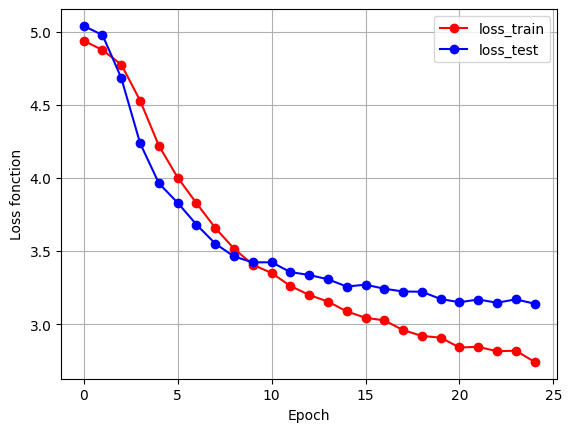

In [162]:
plt.plot(loss_train, 'r' , marker='o', linestyle='-', label = 'loss_train')
plt.plot(loss_val, 'b' , marker='o', linestyle='-', label = 'loss_test')
plt.xlabel('Epoch')
plt.ylabel('Loss fonction')
plt.grid()
plt.legend()
plt.show()

In [165]:
def final_training_data_loader(mean, std, target_size, batch_size=32,
                        apply_augmentation=False,
                        distinguish_classes=False,
                        use_mixup=False,
                        num_classes=50,
                        train_preprocessor_light=None,
                        train_preprocessor_heavy=None,
                        train_preprocessor_uniform=None):

    # 1. On charge le dataset global UNE SEULE FOIS pour tout le monde
    full_dataset = BeeDataset(train=True)

    # CAS 1 : AUCUNE AUGMENTATION
    if not apply_augmentation:
        # On force la création d'un préprocesseur vierge pour garantir l'absence d'augmentation
        preprocessor_none = TorchPreprocessor(
            mean=mean, std=std, normalize=True,
            augmentation="none",
            resize_method="pad", target_size=target_size
        )

        full_dataset.transform = preprocessor_none

        train_dataset_final = full_dataset
        train_sampler = None
        train_shuffle = True

        print(f"Train prêt : {len(train_dataset_final)} images (Pas d'augmentation)")

    else:
        # CAS 2A : AUGMENTATION UNIFORME
        if not distinguish_classes:
            if train_preprocessor_uniform is None:
                train_preprocessor_uniform = TorchPreprocessor(
                    mean=mean, std=std, normalize=True,
                    augmentation="RandAugment",
                    resize_method="pad", target_size=target_size
                )

            full_dataset.transform = train_preprocessor_uniform

            train_dataset_final = full_dataset
            train_sampler = None
            train_shuffle = True

            print(f"Train prêt : {len(train_dataset_final)} images (Augmentation UNIFORME, Tirage CLASSIQUE)")

        # CAS 2B : AUGMENTATION CIBLÉE + RÉÉQUILIBRAGE
        else:
            if train_preprocessor_light is None:
                train_preprocessor_light = TorchPreprocessor(
                    mean=mean, std=std, normalize=True,
                    augmentation="light",
                    resize_method="pad", target_size=target_size
                )

            if train_preprocessor_heavy is None:
                train_preprocessor_heavy = TorchPreprocessor(
                    mean=mean, std=std, normalize=True,
                    augmentation="heavy",
                    resize_method="pad", target_size=target_size
                )

            # On s'assure que le dataset global n'a pas de transformation propre
            full_dataset.transform = None

            labels_train = [sample[1] for sample in full_dataset.samples]
            compte_classes = np.bincount(labels_train)

            # Ciblage
            SEUIL_RARE = 100
            dict_rares = {}
            for classe_idx, compte in enumerate(compte_classes):
                if compte < SEUIL_RARE:
                    dict_rares[classe_idx] = train_preprocessor_heavy

            # Application du Wrapper (TargetedAugmentation) sur le dataset global
            train_dataset_final = TargetedAugmentation(
                dataset_base=full_dataset,
                transform_defaut=train_preprocessor_light,
                dict_transforms_rares=dict_rares
            )

            # Création du Sampler basé sur toutes les données
            poids_classes = 1.0 / (compte_classes + 1e-8)
            poids_echantillons = [poids_classes[label] for label in labels_train]

            train_sampler = WeightedRandomSampler(
                weights=poids_echantillons,
                num_samples=len(poids_echantillons),
                replacement=True
            )
            train_shuffle = False

            print(f"Train prêt : {len(train_dataset_final)} images (Augmentation CIBLÉE, Weighted SAMPLER)")


    # GESTION DU MIXUP
    train_collate_fn = None

    if use_mixup:
        if num_classes is None:
            raise ValueError("Tu dois fournir 'num_classes' si tu actives le Mixup !")
        train_collate_fn = MixupCollate(num_classes=num_classes, alpha=0.2)
        print("-> Mixup : ACTIVÉ (Les labels sont maintenant des probabilités, il faut adapter la loss en conséquence mon coquin)")


    # DATALOADER FINAL
    train_loader = DataLoader(
        train_dataset_final,
        batch_size=batch_size,
        sampler=train_sampler,
        shuffle=train_shuffle,
        collate_fn=train_collate_fn,
        num_workers=2
    )

    return train_loader


In [166]:
train_loader = final_training_data_loader(IMAGENET_MEAN, IMAGENET_STD, target_size=(224, 224),
                                                batch_size=BATCH_SIZE,
                                                apply_augmentation = data_augmentation,
                                                distinguish_classes=data_differntiation,
                                                train_preprocessor_light = train_preprocessor_light,
                                                train_preprocessor_heavy = train_preprocessor_heavy)


NUM_EPOCHS_fin_tune = 5

Path_model = "../results/ConvNeXtFineTune_Antonin_09h58/best_model_epoch_22.pth"

Train prêt : 7999 images (Pas d'augmentation)


In [167]:
model = ConvNeXtFineTune(NUM_CLASSES, DROPOUT, freeze = False, unfreeze = unfreeze)




ConvNeXtFineTune(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm

In [168]:
import csv
import pandas as pd
from sklearn.metrics import confusion_matrix


loss_train = []

for epoch in range(NUM_EPOCHS_fin_tune):

    # ===== TRAIN =====
    train_loss, train_acc, train_f1_macro, train_f1_per_class = train_one_epoch(epoch)
    loss_train.append(train_loss)

    if scheduler:
        scheduler.step()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_fin_tune}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Train F1 Macro: {train_f1_macro:.4f}")


ModelSaver.save_model(model, name=f"best_model_fine_tune.pth")


100%|██████████| 125/125 [01:11<00:00,  1.76it/s]


Train F1 macro: 0.8024

Epoch 1/5
Train Loss: 2.8752 | Train Acc: 0.7965
Train F1 Macro: 0.8024


100%|██████████| 125/125 [01:08<00:00,  1.82it/s]


Train F1 macro: 0.7852

Epoch 2/5
Train Loss: 2.9181 | Train Acc: 0.7948
Train F1 Macro: 0.7852


100%|██████████| 125/125 [01:08<00:00,  1.82it/s]


...

100%|██████████| 125/125 [01:07<00:00,  1.85it/s]


Train F1 macro: 0.7919

Epoch 4/5
Train Loss: 2.9013 | Train Acc: 0.7997
Train F1 Macro: 0.7919


100%|██████████| 125/125 [01:08<00:00,  1.83it/s]


Train F1 macro: 0.7931

Epoch 5/5
Train Loss: 2.9209 | Train Acc: 0.7885
Train F1 Macro: 0.7931


'../results/ConvNeXtFineTune_Antonin_09h58/best_model_fine_tune.pth'

In [182]:
def submission(model, X_test,nom_fichier):
    pred = []
    for img in X_test:

        img = img[0].unsqueeze(0).to(DEVICE)
        pred.append(model.to(DEVICE).inference(img))

    df = pd.DataFrame({
        "id": range(len(pred)),
        "label": pred
    })

    df.to_csv(nom_fichier+".csv", index=False)

In [173]:
test_dataset = BeeDataset(train = False, transform = val_preprocessor)

In [183]:
Path_model = "../results/ConvNeXtFineTune_Antonin_09h58/best_model_epoch_22.pth"
checkpoint = torch.load(
    Path_model,
    map_location=DEVICE
)

model.load_state_dict(checkpoint)
model.to(DEVICE)
model.eval()

ConvNeXtFineTune(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm

In [184]:
submission(model, test_dataset,'best_epoch')

# Entraînement du modèle